# Ejercicio 4: Modelo Probabilístico

---
- **Nombre**: Michael Enríquez
- **Fecha de Entrega**: Lunes 04 de mayo, 2026 

---

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

In [11]:
import os

# Definir la ruta al corpus Gutenberg
gutenberg_dir = os.path.join('..', 'data', 'gutenberg', 'data')
file_names = sorted([f for f in os.listdir(gutenberg_dir) if f.lower().endswith('.txt')])

# Leer hasta 1000 archivos de texto
documents_gutenberg = []
doc_ids = []
for file_name in file_names[:1000]:
    file_path = os.path.join(gutenberg_dir, file_name)
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        text = f.read().replace('\n', ' ').strip()
        if text:
            documents_gutenberg.append(text)
            doc_ids.append(file_name)

print(f"Archivos de Gutenberg encontrados: {len(file_names)}")
print(f"Documentos cargados en el corpus Gutenberg 1000: {len(documents_gutenberg)}")
print("Primeros 5 archivos del corpus:")
for name in doc_ids[:5]:
    print(f"- {name}")

Archivos de Gutenberg encontrados: 957
Documentos cargados en el corpus Gutenberg 1000: 957
Primeros 5 archivos del corpus:
- pg10.txt
- pg100.txt
- pg10002.txt
- pg10102.txt
- pg10148.txt


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Utiliza el corpus cargado.
2. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
3. Calcula TF-IDF utilizando sklearn.
4. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [12]:
import pandas as pd

# Crear DataFrame con los documentos de Gutenberg
df = pd.DataFrame({'document': documents_gutenberg, 'doc_id': doc_ids})
df

,document,doc_id
0,﻿The Project Gutenberg eBook of The King James...,pg10.txt
1,﻿The Project Gutenberg eBook of The Complete W...,pg100.txt
2,﻿The Project Gutenberg eBook of The House on t...,pg10002.txt
3,﻿The Project Gutenberg eBook of The Czar's Spy...,pg10102.txt
4,﻿The Project Gutenberg eBook of The Merry Adve...,pg10148.txt
...,...,...
952,﻿The Project Gutenberg eBook of I. Beowulf: an...,pg9701.txt
953,﻿The Project Gutenberg eBook of The Secret Age...,pg974.txt
954,﻿The Project Gutenberg eBook of A Tale of Two ...,pg98.txt
955,﻿The Project Gutenberg eBook of The Torrents o...,pg9911.txt


In [13]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

def preprocess_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Remover puntuación
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenizar
    tokens = word_tokenize(text)
    # Remover stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Unir de nuevo
    return ' '.join(tokens)

df['prep'] = df['document'].apply(preprocess_text)
df

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Michael\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Michael\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Michael\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,document,doc_id,prep
0,﻿The Project Gutenberg eBook of The King James...,pg10.txt,project gutenberg ebook king james version bib...
1,﻿The Project Gutenberg eBook of The Complete W...,pg100.txt,project gutenberg ebook complete works william...
2,﻿The Project Gutenberg eBook of The House on t...,pg10002.txt,project gutenberg ebook house borderland ebook...
3,﻿The Project Gutenberg eBook of The Czar's Spy...,pg10102.txt,project gutenberg ebook czars spy mystery sile...
4,﻿The Project Gutenberg eBook of The Merry Adve...,pg10148.txt,project gutenberg ebook merry adventures robin...
...,...,...,...
952,﻿The Project Gutenberg eBook of I. Beowulf: an...,pg9701.txt,project gutenberg ebook beowulf anglosaxon poe...
953,﻿The Project Gutenberg eBook of The Secret Age...,pg974.txt,project gutenberg ebook secret agent simple ta...
954,﻿The Project Gutenberg eBook of A Tale of Two ...,pg98.txt,project gutenberg ebook tale two cities ebook ...
955,﻿The Project Gutenberg eBook of The Torrents o...,pg9911.txt,project gutenberg ebook torrents spring ebook ...


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['prep'])

In [15]:
query = 'government'
q_proc = preprocess_text(query)
q_vec = vectorizer.transform([query])

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

df['q_sim'] = cosine_similarity(X, q_vec)
df.sort_values(by='q_sim', ascending=False)

,document,doc_id,prep,q_sim
100,﻿The Project Gutenberg eBook of The Life of Ge...,pg18595.txt,project gutenberg ebook life george washington...,0.192700
903,﻿The Project Gutenberg eBook of Second Treatis...,pg7370.txt,project gutenberg ebook second treatise govern...,0.190301
197,﻿The Project Gutenberg eBook of An Introductio...,pg21660.txt,project gutenberg ebook introduction industria...,0.184123
151,﻿The Project Gutenberg eBook of The Government...,pg21006.txt,project gutenberg ebook governments europe ebo...,0.180592
526,﻿The Project Gutenberg eBook of Lord Milner's ...,pg26490.txt,project gutenberg ebook lord milners work sout...,0.167186
...,...,...,...,...
887,﻿The Project Gutenberg eBook of Jud Süß ...,pg69944.txt,project gutenberg ebook jud süß ebook use anyo...,0.000000
913,﻿The Project Gutenberg eBook of Fenn Kaß ...,pg76309.txt,project gutenberg ebook fenn kaß ebook use any...,0.000000
912,﻿The Project Gutenberg eBook of I am a woman ...,pg76178.txt,project gutenberg ebook woman ebook use anyone...,0.000000
911,﻿The Project Gutenberg eBook of Adventures of ...,pg76.txt,project gutenberg ebook adventures huckleberry...,0.000000


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [17]:
try:
    from rank_bm25 import BM25Okapi
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rank-bm25'])
    from rank_bm25 import BM25Okapi

import numpy as np

# Tokenizar los documentos preprocesados para BM25
tokenized_corpus = [doc.split() for doc in df['prep']]

# Crear el modelo BM25
bm25 = BM25Okapi(tokenized_corpus)

# Procesar la consulta
query_tokenized = preprocess_text(query).split()

# Calcular scores BM25
bm25_scores = bm25.get_scores(query_tokenized)

# Agregar al DataFrame
df['bm25_score'] = bm25_scores

# Ranking con BM25
df_bm25_ranked = df.sort_values(by='bm25_score', ascending=False)
df_bm25_ranked[['doc_id', 'bm25_score']].head(10)

,doc_id,bm25_score
526,pg26490.txt,3.770832
151,pg21006.txt,3.769043
389,pg24780.txt,3.767650
903,pg7370.txt,3.766576
100,pg18595.txt,3.766444
153,pg21012.txt,3.766169
197,pg21660.txt,3.764152
587,pg27430.txt,3.763606
651,pg28169.txt,3.762977
303,pg22815.txt,3.762459


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. Identifica: ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. Sugiere: ¿A qué se podría deber esta diferencia?

Top 10 documentos según TF-IDF:
     doc_id    q_sim  bm25_score
pg18595.txt 0.192700    3.766444
 pg7370.txt 0.190301    3.766576
pg21660.txt 0.184123    3.764152
pg21006.txt 0.180592    3.769043
pg26490.txt 0.167186    3.770832
pg28169.txt 0.159738    3.762977
pg27430.txt 0.148589    3.763606
pg21012.txt 0.133819    3.766169
pg20982.txt 0.124769    3.762418
pg22849.txt 0.121799    3.755536

Top 10 documentos según BM25:
     doc_id  bm25_score    q_sim
pg26490.txt    3.770832 0.167186
pg21006.txt    3.769043 0.180592
pg24780.txt    3.767650 0.112543
 pg7370.txt    3.766576 0.190301
pg18595.txt    3.766444 0.192700
pg21012.txt    3.766169 0.133819
pg21660.txt    3.764152 0.184123
pg27430.txt    3.763606 0.148589
pg28169.txt    3.762977 0.159738
pg22815.txt    3.762459 0.112174


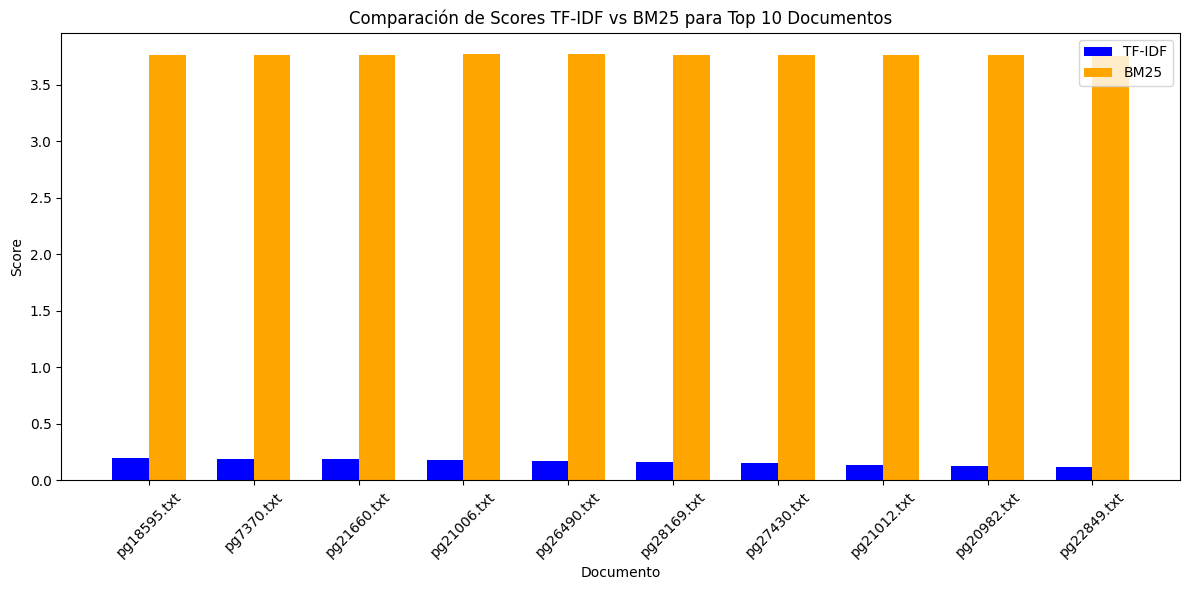


Diferencias observadas:
- Solo en Top 10 TF-IDF (no en BM25): ['pg20982.txt', 'pg22849.txt']
- Solo en Top 10 BM25 (no en TF-IDF): ['pg24780.txt', 'pg22815.txt']
- Documentos en ambos Top 10: ['pg18595.txt', 'pg7370.txt', 'pg21660.txt', 'pg21006.txt', 'pg26490.txt', 'pg28169.txt', 'pg27430.txt', 'pg21012.txt']

Posible razón: BM25 penaliza términos frecuentes en documentos largos, mientras TF-IDF los pondera por IDF global.


In [23]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib'])
    import matplotlib.pyplot as plt

import numpy as np

# Tomar los top 10 documentos por TF-IDF
top_tfidf = df.sort_values(by='q_sim', ascending=False).head(10).copy()

# Comparar con BM25 para esos mismos documentos
top_tfidf['bm25_score'] = df.set_index('doc_id').loc[top_tfidf['doc_id']]['bm25_score'].values

print('Top 10 documentos según TF-IDF:')
print(top_tfidf[['doc_id', 'q_sim', 'bm25_score']].to_string(index=False))

print('\nTop 10 documentos según BM25:')
top_bm25 = df.sort_values(by='bm25_score', ascending=False).head(10)[['doc_id', 'bm25_score', 'q_sim']]
print(top_bm25.to_string(index=False))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top_tfidf))
width = 0.35

ax.bar(x - width/2, top_tfidf['q_sim'], width, label='TF-IDF', color='blue')
ax.bar(x + width/2, top_tfidf['bm25_score'], width, label='BM25', color='orange')

ax.set_xlabel('Documento')
ax.set_ylabel('Score')
ax.set_title('Comparación de Scores TF-IDF vs BM25 para Top 10 Documentos')
ax.set_xticks(x)
ax.set_xticklabels(top_tfidf['doc_id'], rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

print('\nDiferencias observadas:')

# Top 10 de cada modelo
top10_tfidf = df.sort_values(by='q_sim', ascending=False).head(10)['doc_id'].tolist()
top10_bm25 = df.sort_values(by='bm25_score', ascending=False).head(10)['doc_id'].tolist()

# Documentos únicos en cada ranking
solo_en_tfidf = [doc for doc in top10_tfidf if doc not in top10_bm25]
solo_en_bm25 = [doc for doc in top10_bm25 if doc not in top10_tfidf]

print(f'- Solo en Top 10 TF-IDF (no en BM25): {solo_en_tfidf}')
print(f'- Solo en Top 10 BM25 (no en TF-IDF): {solo_en_bm25}')
print(f'- Documentos en ambos Top 10: {[doc for doc in top10_tfidf if doc in top10_bm25]}')
print('\nPosible razón: BM25 penaliza términos frecuentes en documentos largos, mientras TF-IDF los pondera por IDF global.')